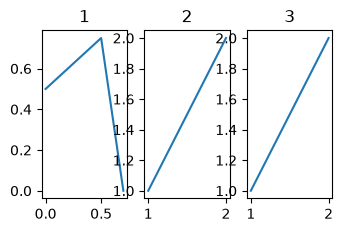

In [24]:
#標準寫法
import matplotlib.pyplot as plt
import numpy as np

# 1.製作figure
fig = plt.figure()

# 2.在1.的figure上製作一個axes
ax_1 = fig.add_subplot(2, 5, 1)
ax_1.set_title('1')  #圖的標題
ax_2 = fig.add_subplot(2, 5, 2)
ax_2.set_title('2')  #圖的標題
ax_3 = fig.add_subplot(2, 5, 3)
ax_3.set_title('3')  #圖的標題
# 3.將圖的數據儲存在axes中
X_1 = [0, 0.5,  0.7]
Y_1 = [0.5, 0.75,  0]
ax_1.plot(X_1, Y_1)

X_2 = [1, 1.5, 2]
Y_2 = [1, 1.5,  2]
ax_2.plot(X_2, Y_2)

X_3 = [1, 1.5, 2]
Y_3 = [1, 1.5,  2]
ax_3.plot(X_2, Y_2)
# 4.顯示圖
plt.show()

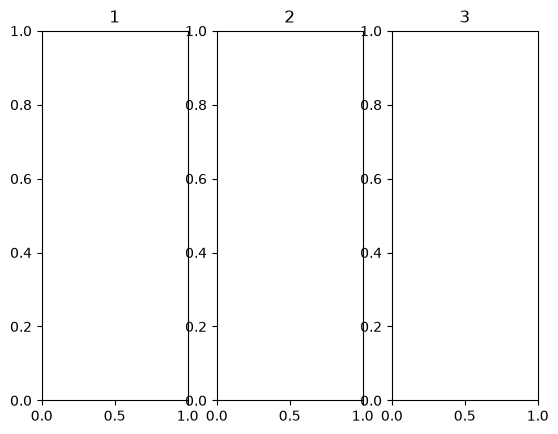

In [6]:
import matplotlib.pyplot as plt

#製作figure
fig = plt.figure()

# 1x3的矩陣的第1個位置中設定axes
ax_1 = fig.add_subplot(1, 3, 1)
ax_1.set_title('1')  #圖的標題

# 1x3的矩陣的第2個位置中設定axes
ax_2 = fig.add_subplot(1, 3, 2)
ax_2.set_title('2')  #圖的標題

# 1x3的矩陣的第3個位置中設定axes
ax_3 = fig.add_subplot(1, 3, 3)
ax_3.set_title('3')  #圖的標題

#顯示圖
plt.show()

In [40]:
import pandas as pd

df = pd.read_csv("考試分數_3年6班.csv", encoding="utf-8-sig")
call = df[df["數學"]>= 80]
print(call.head())
#df

  學生姓名  語文  數學  英語  物理  化學
0  王小明  85  92  78  88  90
1  李美芳  90  88  95  82  85
2  張家豪  75  80  70  72  78
3  陳建宏  82  85  80  85  88
5  黃淑惠  92  95  90  94  92


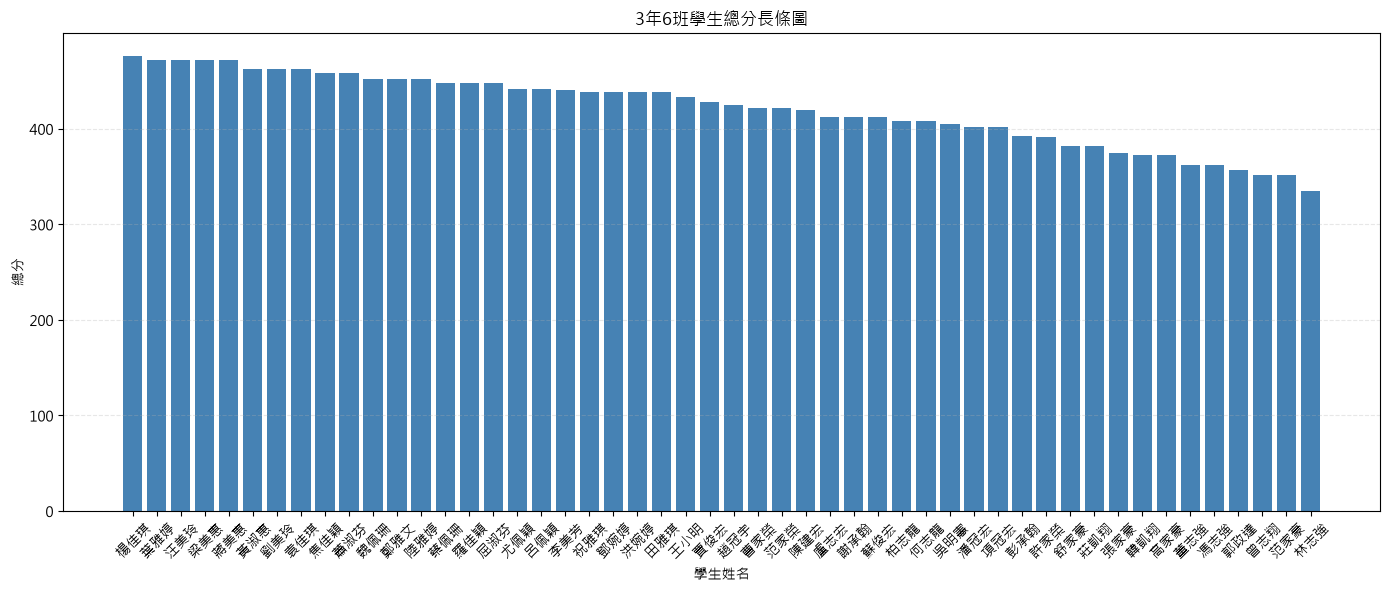

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 讀取 CSV 檔
df = pd.read_csv("考試分數_3年6班.csv", encoding="utf-8-sig")

# 計算總分
df["總分"] = df[["語文", "數學", "英語", "物理", "化學"]].sum(axis=1)

# 依總分排序
df = df.sort_values("總分", ascending=False)


# 設定中文字型（若你的環境有這些字型，中文才會正常顯示）
plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei", "SimHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

# 建立圖表
plt.figure(figsize=(14, 6))
plt.bar(df["學生姓名"], df["總分"], color="steelblue")

# 標題與座標軸
plt.title("3年6班學生總分長條圖")
plt.xlabel("學生姓名")
plt.ylabel("總分")

# X 軸文字旋轉，避免重疊
plt.xticks(rotation=45)

# 顯示格線
plt.grid(axis="y", linestyle="--", alpha=0.3)

# 顯示圖表
plt.tight_layout()
plt.show()

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

font = FontProperties(fname="/System/Library/Fonts/STHeiti Medium.ttc")

# 讀取 CSV
df = pd.read_csv("考試分數_3年6班.csv")

# 篩選趙冠宇的資料
zhao = df[df["學生姓名"] == "陳建宏"]

# 取出各科成績
scores = zhao.iloc[0][["語文", "數學", "英語", "物理", "化學"]]

# 繪製長條圖
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(1, 1, 1)

ax.bar(scores.index, scores.values)

ax.set_title("趙冠宇成績", fontproperties=font)
ax.set_xlabel("科目", fontproperties=font)
ax.set_ylabel("分數", fontproperties=font)
ax.set_ylim(0, 100)
ax.set_xticks(range(len(scores.index)))
ax.set_xticklabels(scores.index, fontproperties=font)

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\System\\Library\\Fonts\\STHeiti Medium.ttc'

<Figure size 600x400 with 1 Axes>

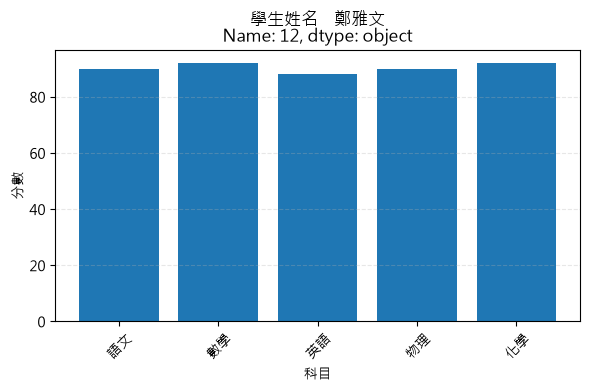

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# 讀取 CSV 檔
df = pd.read_csv("考試分數_3年6班.csv", encoding="utf-8-sig")

# 篩選陳建宏的資料
zhao = df[df["學生姓名"] == "鄭雅文"]

# 取出各科成績
scores = zhao.iloc[0][["語文", "數學", "英語", "物理", "化學"]]
name = zhao.iloc[0][["學生姓名"]]

# 設定中文字型（若你的環境有這些字型，中文才會正常顯示）
plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei", "SimHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

# 建立圖表
# 繪製長條圖
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(1, 1, 1)


ax.bar(scores.index, scores.values)

# 標題與座標軸
#plt.title("陳建宏成績")
plt.title(str(name))
plt.xlabel("科目")
plt.ylabel("分數")

# X 軸文字旋轉，避免重疊
plt.xticks(rotation=45)

# 顯示格線
plt.grid(axis="y", linestyle="--", alpha=0.3)

# 顯示圖表
plt.tight_layout()
plt.show()

In [53]:
from pathlib import Path
import tkinter as tk
from tkinter import ttk, messagebox

import pandas as pd


class ScoreViewerApp:
	def __init__(self, root: tk.Tk) -> None:
		self.root = root
		self.root.title("學生成績檢視器")
		self.root.geometry("900x560")

		self.subject_columns = ["語文", "數學", "英語", "物理", "化學"]
		self.df = self._load_data()
		self.names = self.df["學生姓名"].tolist()

		self.selected_name = tk.StringVar()
		self.summary_var = tk.StringVar(value="請先選擇一位學生")

		self._build_ui()

		if self.names:
			self.selected_name.set(self.names[0])
			self.on_name_changed()

	def _load_data(self) -> pd.DataFrame:
		csv_path = Path(__file__).with_name("考試分數_3年6班.csv")
		try:
			df = pd.read_csv(csv_path)
		except Exception as exc:
			messagebox.showerror("讀取失敗", f"無法讀取資料檔：\n{csv_path}\n\n{exc}")
			raise

		required = ["學生姓名", "語文", "數學", "英語", "物理", "化學"]
		missing = [col for col in required if col not in df.columns]
		if missing:
			messagebox.showerror("欄位錯誤", f"CSV 缺少必要欄位：{', '.join(missing)}")
			raise ValueError("CSV 欄位不完整")

		return df

	def _build_ui(self) -> None:
		container = tk.Frame(self.root, padx=14, pady=14)
		container.pack(fill=tk.BOTH, expand=True)

		top = tk.Frame(container)
		top.pack(fill=tk.X)

		tk.Label(top, text="請選擇學生姓名：", font=("Arial", 12, "bold")).pack(side=tk.LEFT)

		name_box = ttk.Combobox(
			top,
			textvariable=self.selected_name,
			values=self.names,
			width=18,
			state="readonly",
			font=("Arial", 12),
		)
		name_box.pack(side=tk.LEFT, padx=8)
		name_box.bind("<<ComboboxSelected>>", lambda _event: self.on_name_changed())

		tk.Label(top, textvariable=self.summary_var, fg="navy", font=("Arial", 11)).pack(side=tk.LEFT, padx=16)

		body = tk.Frame(container)
		body.pack(fill=tk.BOTH, expand=True, pady=(12, 0))

		left_panel = tk.LabelFrame(body, text="分數明細", padx=10, pady=10)
		left_panel.pack(side=tk.LEFT, fill=tk.Y)

		self.tree = ttk.Treeview(left_panel, columns=("subject", "score"), show="headings", height=8)
		self.tree.heading("subject", text="科目")
		self.tree.heading("score", text="分數")
		self.tree.column("subject", width=120, anchor=tk.CENTER)
		self.tree.column("score", width=80, anchor=tk.CENTER)
		self.tree.pack(fill=tk.BOTH, expand=True)

		chart_panel = tk.LabelFrame(body, text="成績圖表", padx=10, pady=10)
		chart_panel.pack(side=tk.LEFT, fill=tk.BOTH, expand=True, padx=(12, 0))

		self.chart_canvas = tk.Canvas(chart_panel, bg="white", highlightthickness=0)
		self.chart_canvas.pack(fill=tk.BOTH, expand=True)
		self.chart_canvas.bind("<Configure>", lambda _event: self.on_name_changed())

	def on_name_changed(self) -> None:
		name = self.selected_name.get().strip()
		if not name:
			return

		row = self.df[self.df["學生姓名"] == name]
		if row.empty:
			messagebox.showwarning("找不到學生", f"查無學生：{name}")
			return

		scores = row.iloc[0][self.subject_columns].astype(float)
		self._refresh_score_table(scores)
		self._refresh_chart(name, scores)

		total = int(scores.sum())
		avg = scores.mean()
		self.summary_var.set(f"總分：{total}    平均：{avg:.1f}")

	def _refresh_score_table(self, scores: pd.Series) -> None:
		for item_id in self.tree.get_children():
			self.tree.delete(item_id)

		for subject, score in scores.items():
			self.tree.insert("", tk.END, values=(subject, int(score)))

	def _refresh_chart(self, name: str, scores: pd.Series) -> None:
		canvas = self.chart_canvas
		canvas.delete("all")

		width = max(canvas.winfo_width(), 500)
		height = max(canvas.winfo_height(), 360)

		left_pad = 55
		right_pad = 20
		top_pad = 45
		bottom_pad = 60

		plot_w = width - left_pad - right_pad
		plot_h = height - top_pad - bottom_pad

		if plot_w <= 0 or plot_h <= 0:
			return

		# 座標軸
		x0 = left_pad
		y0 = height - bottom_pad
		x1 = width - right_pad
		y1 = top_pad
		canvas.create_line(x0, y0, x1, y0, width=2, fill="#444")
		canvas.create_line(x0, y0, x0, y1, width=2, fill="#444")

		# 標題與軸標籤
		canvas.create_text(width / 2, 20, text=f"{name} 成績", font=("Helvetica", 16, "bold"), fill="#1f2937")
		canvas.create_text(width / 2, height - 20, text="科目", font=("Helvetica", 11), fill="#374151")
		canvas.create_text(18, height / 2, text="分數", angle=90, font=("Helvetica", 11), fill="#374151")

		# Y 軸刻度
		for tick in range(0, 101, 20):
			y = y0 - (tick / 100) * plot_h
			canvas.create_line(x0 - 5, y, x0, y, fill="#666")
			canvas.create_text(x0 - 20, y, text=str(tick), font=("Helvetica", 10), fill="#4b5563")
			if tick > 0:
				canvas.create_line(x0, y, x1, y, fill="#e5e7eb")

		colors = ["#4e79a7", "#f28e2b", "#e15759", "#76b7b2", "#59a14f"]
		subjects = list(scores.index)
		values = [float(v) for v in scores.values]
		count = len(subjects)
		slot_w = plot_w / count
		bar_w = slot_w * 0.58

		for idx, (subject, value) in enumerate(zip(subjects, values)):
			cx = x0 + slot_w * (idx + 0.5)
			bar_h = (value / 100) * plot_h
			bx0 = cx - bar_w / 2
			by0 = y0 - bar_h
			bx1 = cx + bar_w / 2
			by1 = y0

			canvas.create_rectangle(bx0, by0, bx1, by1, fill=colors[idx % len(colors)], outline="")
			canvas.create_text(cx, by0 - 12, text=str(int(value)), font=("Helvetica", 10, "bold"), fill="#111827")
			canvas.create_text(cx, y0 + 18, text=subject, font=("Helvetica", 11), fill="#374151")


def main() -> None:
	root = tk.Tk()
	ScoreViewerApp(root)
	root.mainloop()


if __name__ == "__main__":
    main()

NameError: name '__file__' is not defined